In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os
import plotly.express as px
import matplotlib.pyplot as plt
os.chdir('/Users/tactile/Downloads/')
df = pd.read_csv("df_glove_modes_type.csv")
df = df[df["acc_type"] == "acc_lp"]
df_all = df
df = df[df["Glove_Mode"] == 0]

df_all["True_L"] = pd.Categorical(df_all["True_L"],
                              categories=["Top", "Middle", "Bottom"],
                              ordered=True)
df_all["True_S"] = pd.Categorical(df_all["True_S"],
                              categories=["Small", "Medium", "Large"],
                              ordered=True)
# df_all["Glove_Mode"] = df_all["Glove_Mode"].astype(str)   
df_all["Glove_Mode"] = df_all["Glove_Mode"].map({
    0: "Bare hand",
    1: "Wearing glove"})
df_all


,True_LP,True_S,True_L,LP_p,S_p,L_p,Participant,Prototype,acc_type,Accuracy,Glove_Mode
0,Lump,Small,Top,1,1,2,0,1_0_0,acc_lp,1.000,Bare hand
3,Lump,Small,Top,1,0,2,1,1_0_0,acc_lp,1.000,Bare hand
6,Lump,Small,Top,1,1,0,2,1_0_0,acc_lp,1.000,Bare hand
9,Lump,Small,Top,1,1,0,3,1_0_0,acc_lp,1.000,Bare hand
12,Lump,Small,Top,1,0,1,4,1_0_0,acc_lp,0.875,Bare hand
...,...,...,...,...,...,...,...,...,...,...,...
525,Lump,Large,Bottom,1,2,1,5,1_2_2,acc_lp,1.000,Wearing glove
528,Lump,Large,Bottom,0,-1,-1,6,1_2_2,acc_lp,0.875,Wearing glove
531,Lump,Large,Bottom,0,-1,-1,7,1_2_2,acc_lp,0.125,Wearing glove
534,Lump,Large,Bottom,1,1,1,8,1_2_2,acc_lp,0.875,Wearing glove


### BOX PLOT FOR GLOVE MODES

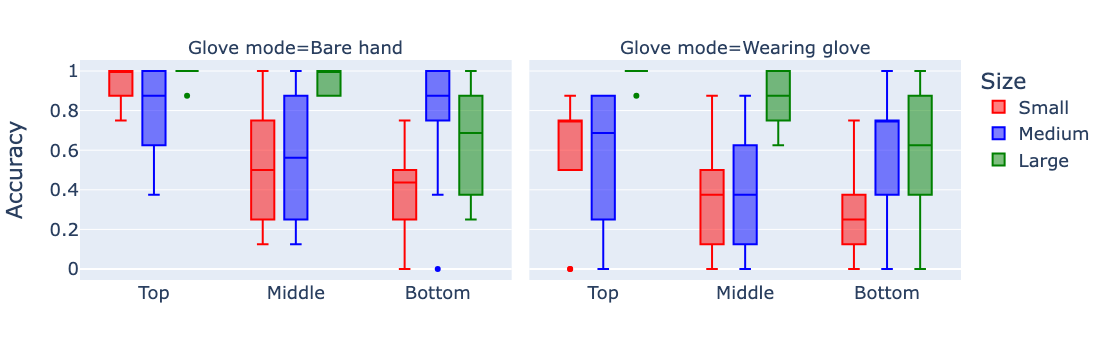

In [ ]:
    fig = px.box(
        df_all,
        x = "True_L",
        y = "Accuracy",
        color = "True_S",
        color_discrete_sequence=["red", "blue", "green"],
        facet_col = "Glove_Mode",
        category_orders={
            "True_L": ["Top", "Middle", "Bottom"],
            "True_S": ["Small", "Medium", "Large"],
            "Glove_Mode": ["Bare hand", "Wearing glove"],   # list of categories
        },
        labels={
            "True_L": "",
            "Accuracy": "Accuracy",
            "True_S": "Size",
            "Glove_Mode": "Glove mode",                     # single string
        },
        
    )
    
    fig.update_traces(quartilemethod="exclusive") # or "inclusive", or "linear" by default
    fig.update_layout(
        font=dict(size=18),
        boxmode="group"
    )
    
    fig.show()
    fig.write_image("box_glove_mod.pdf")


### GRAPH CONF MATRIX TO LINES

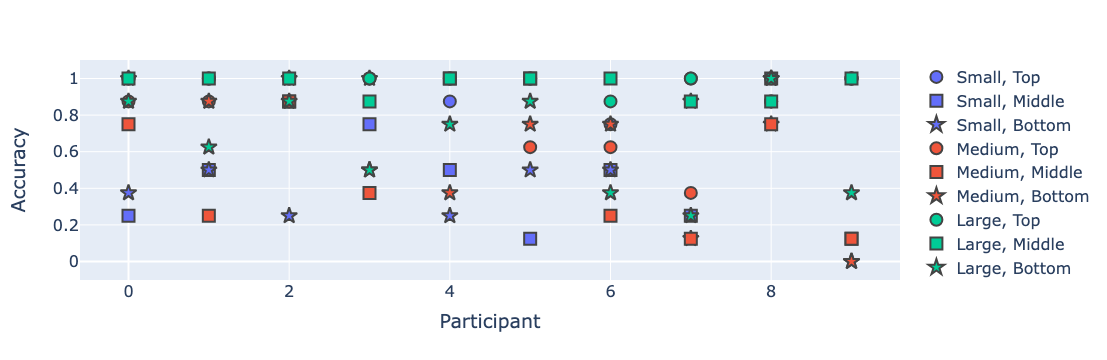

In [ ]:
symbol_map = {
    "Top": "circle",
    "Middle": "square",
    "Bottom": "star"
}
fig = px.scatter(
    df,
    x="Participant",
    y="Accuracy",
    color="True_S",      # colour = size
    symbol="True_L",    
    symbol_map=symbol_map,
    labels={
        "Accuracy": "Accuracy",
        "Participant": "Participant",
        "True_S": "Size",
        "True_L": "Location"
    }
)

fig.update_layout(
    font=dict(size=16),
    legend_title_text="",          # optional
)

fig.update_traces(
    marker_size=12,
    marker_line=dict(width=2),
    selector=dict(mode="markers")
)

fig.show()

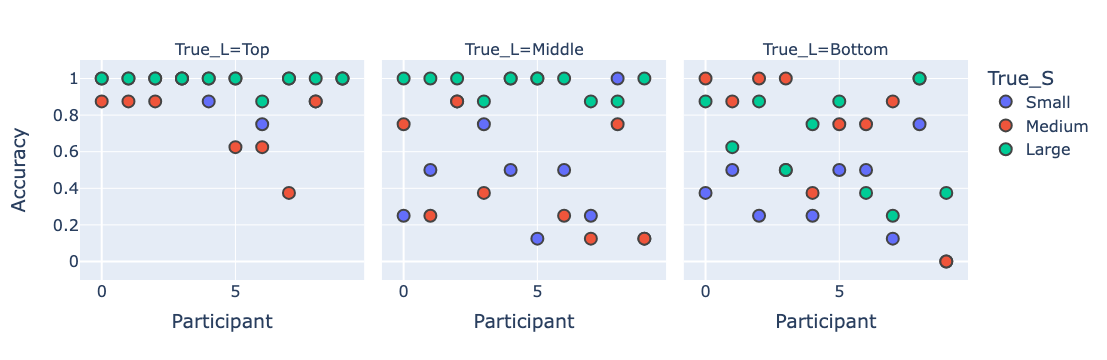

In [32]:
fig = px.scatter(
    df,
    x = "Participant",
    y = "Accuracy",
    color = "True_S",   
    facet_col = "True_L",
    labels = {
        "condition": "Location | Size",
        "Accuracy": "Accuracy",
        "Participant": "Participant"
    },   
)
fig.update_layout(
    font=dict(size=16),
    )
fig.update_traces(
    marker_size=12,
    marker_line=dict(width=2),
    selector=dict(mode='markers')
    )
fig.show()


### new sensor config

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import os
import plotly.express as px
import matplotlib.pyplot as plt
os.chdir('/Users/tactile/Downloads/')

In [4]:
def plot_config(
    df_config, title, plot_title, save, doc, t):

    fig = px.scatter(
        df_config,
        x="num_seconds",
        y=column_title,
        color="task",      # colour = size
        facet_col="sensor_config",
        facet_row="doctor_trials",
        facet_col_spacing = 0.06,
        symbol="task",  
        symbol_map=symbol_map,
        labels={
            "Accuracy": "Accuracy (%)",
            "task": "task",
            "Sensor_config": "Sensor_config",
            "num_seconds": "Time [s]",
            column_title: "F1-score"
        }
    )
    fig.for_each_annotation(
        lambda a: a.update(y=a.y + 0.04, text=a.text.split("=")[-1]))
    
    fig.update_yaxes(
        matches='y', 
        showticklabels=True)
    
    Y_AXIS_RANGE = [0, 100]

    fig.update_layout(
        font=dict(
            size=25),
        legend_title_text="", 
        legend=dict(
            orientation="h",      # horizontal legend
            yanchor="bottom",
            y=1.25,               # a bit above the top of the plot
            xanchor="center",
            x=0.6                 # centered
        ),
         margin=dict(
            l=0,   # left
            r=45,   # right
            t=50,  # top  (keep some space for title / legend)
            b=0    # bottom
        ),
        width = 1000,
        height = 300,
        yaxis_range=Y_AXIS_RANGE
    )
    #######
    facet_value = fig.layout.annotations[3].text.split("=")[-1]
    
    if doc == False:
        facet_value = str(int(facet_value)+0)
        
    fig.layout.annotations[3].text = t #"Added trials: " + facet_value
    ########
    task_map = {
        "lump_binary": "Lump Presence",
        "size_multiclass": "Size",
        "position_multiclass": "Location"
    }
    for i, label in enumerate(task_map):
        fig.layout.annotations[i]['text'] = task_map[label]
        
    #######       
    s_config_names = {"tips":"Distal",
                 "tips and middle":"Distal and Intermediate", 
                 "all": "All"
                }
    
    for i, label in enumerate(s_config_names):
        fig.layout.annotations[i]['text'] = s_config_names[label]
        
    ########
    fig.update_traces(
        marker_size=12,
        selector=dict(mode="markers"),
        marker = dict(
            opacity=0.7),
        marker_line=dict(width=2)
    )
    fig.show()
    if (save == True):
        fig.write_image("/Users/tactile/Downloads/"+title)    
    return fig

def preprocess_data(
        df, val):
    
    df = df.dropna(subset = "avg_f1_stl")
    if val == True:
        df = df[~((df["eval_set"]=="val") & (df["doctor_trials"]==0))]
    elif val == False:
        df = df[((df["eval_set"]=="val") & (df["doctor_trials"]==0))]
    df_raw_group = df[df["cv_type"]=="group"]
    df_raw_plain = df[df["cv_type"]=="plain"]
    df_val_group = df_raw_group[df_raw_group["eval_set"]=="val"]
    df_val_plain = df_raw_plain[df_raw_plain["eval_set"]=="val"]
    
    return df_raw_group.reset_index(drop=True), df_raw_plain.reset_index(drop=True), df_val_group.reset_index(drop=True), df_val_plain.reset_index(drop=True)
    # return df_raw_group.reset_index(drop=True), df_raw_plain.reset_index(drop=True), df_val_group.reset_index(drop=True), df_val_plain.reset_index(drop=True)

def preproc_mtl(
    df, index, task):
    
    df_1 = pd.concat([df[df.columns[0:8]],\
                      df[df.columns[index]]], axis = 1)
    df_1 = df_1.rename(columns={str(df_1.columns[-1]) : 'avg_f1_stl'})
    df_1["task"] = df_1["task"].replace({str(df_1["task"][0]): str(task)})
    df_1.reset_index(drop=True)
    return df_1
    
def concat_mtl(
    df):
    
    df_l = preproc_mtl(df, 14, "Lump Presence")
    df_s = preproc_mtl(df, 19, "Size")
    df_p = preproc_mtl(df, 24, "Location")
    
    df = pd.concat([df_l, df_s, df_p], axis = 0)
    df = df.reset_index(drop=True)
    return df

In [ ]:
df_raw_STL = pd.read_csv("sensor_config_STL.csv")
df_raw_MTL = pd.read_csv("sensor_config_MTL.csv")

task_map = {
        "lump_binary": "Lump Presence",
        "size_multiclass": "Size",
        "position_multiclass": "Location"
    }

df_group_MTL_, df_plain_MTL_, _ , _ = preprocess_data(df_raw_MTL, True)
df_group_STL, df_plain_STL, _ , _ = preprocess_data(df_raw_STL, True)
df_group_STL["task"] = df_group_STL["task"].map(task_map)
df_plain_STL["task"] = df_plain_STL["task"].map(task_map)

df_group_MTL = concat_mtl(df_group_MTL_)
df_plain_MTL = concat_mtl(df_plain_MTL_)

# for i in range(2):
#     plot_config(df_group_MTL[df_group_MTL["doctor_trials"]==i], 
#                 "sensor_config_trial_df_group_MTL" + str(i) + ".pdf","df_group_MTL", True, False)
#     plot_config(df_plain_MTL[df_plain_MTL["doctor_trials"]==i], 
#                 "sensor_config_trial_df_plain_MTL" + str(i) + ".pdf", "df_plain_MTL", True, False)
#     plot_config(df_group_STL[df_group_STL["doctor_trials"]==i], 
#                 "sensor_config_trial_df_group_STL" + str(i) + ".pdf", "df_group_STL", True, False)
#     plot_config(df_plain_STL[df_plain_STL["doctor_trials"]==i], 
#                 "sensor_config_trial_df_plain_STL" + str(i) + ".pdf", "df_plain_STL", True, False)

TypeError: Index(...) must be called with a collection of some kind, 'avg_f1_stl' was passed

In [619]:
#VAL = 0
df_group_MTL_val, df_plain_MTL_val, _ , _ = preprocess_data(df_raw_MTL, False)
df_group_STL_val, df_plain_STL_val, _ , _ = preprocess_data(df_raw_STL, False)
df_group_MTL_val = concat_mtl(df_group_MTL_val)
df_plain_MTL_val = concat_mtl(df_plain_MTL_val)
df_group_STL_val["task"] = df_group_STL_val["task"].map(task_map)
df_plain_STL_val["task"] = df_plain_STL_val["task"].map(task_map)

### SINGLE TASK LEARNING PLOTS FOR PAPER


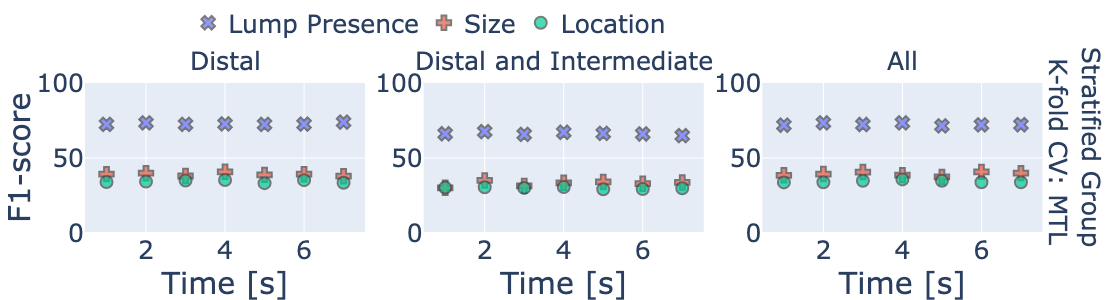

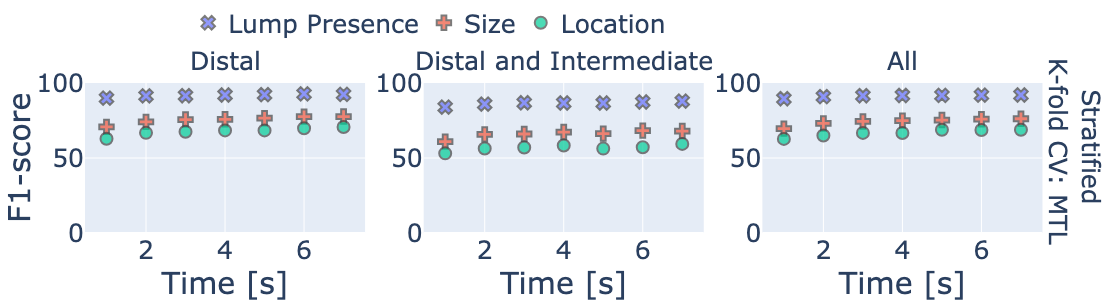

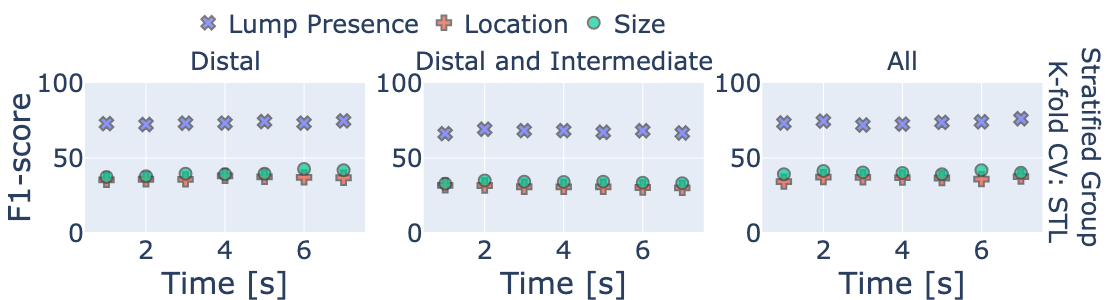

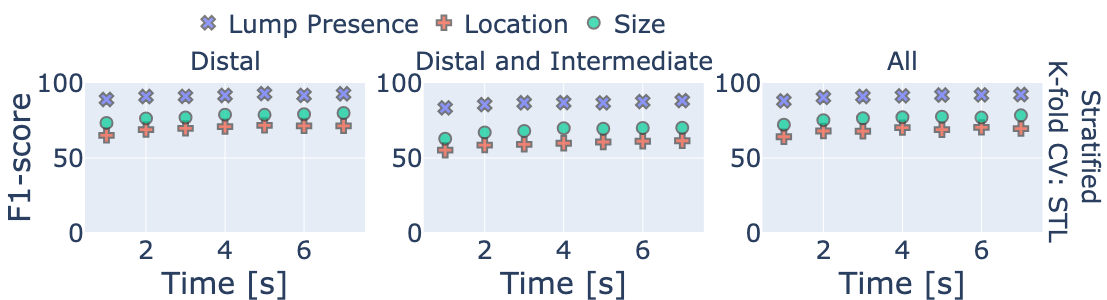

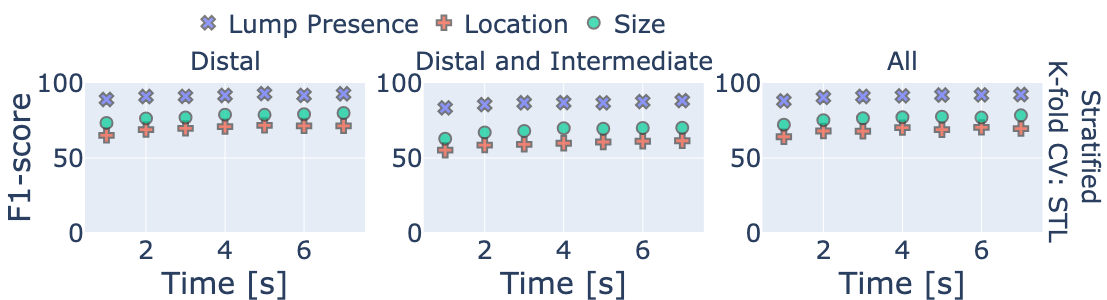

In [650]:
i = 0
plot_config(df_group_MTL_val, 
            "sensor_config_val_df_group_MTL" + str(i) + ".pdf","df_group_MTL", True, False, "Stratified Group <br>K-fold CV: MTL")
plot_config(df_plain_MTL_val, 
            "sensor_config_val_df_plain_MTL" + str(i) + ".pdf", "df_plain_MTL", True, False, "Stratified <br>K-fold CV: MTL")
plot_config(df_group_STL_val, 
            "sensor_config_val_df_group_STL" + str(i) + ".pdf", "df_group_STL", True, False, "Stratified Group <br>K-fold CV: STL")
plot_config(df_plain_STL_val, 
            "sensor_config_val_df_plain_STL" + str(i) + ".pdf", "df_plain_STL", True, False, "Stratified <br>K-fold CV: STL")